In [130]:
import os
from dotenv import load_dotenv
from langchain_openai import ChatOpenAI, OpenAIEmbeddings
from typing_extensions import TypedDict
from pydantic import BaseModel, Field
from langgraph.graph import StateGraph, START, END
from langgraph.checkpoint.memory import MemorySaver
from IPython.display import Image, display
from langchain_chroma import Chroma
from langchain_core.documents import Document
import pandas as pd

In [120]:
load_dotenv()

os.environ.get("OPENAI_API_KEY")

llm = ChatOpenAI(model="gpt-5.4-mini", temperature=0.7, api_key=os.environ.get("OPENAI_API_KEY"))

# Graph State


In [ ]:
class State(TypedDict):
    issue: str
    sub_issue: str
    product: str
    sub_product: str
    narrative: str
    valid_issue: str
    valid_sub_issue: str
    valid_product: str
    valid_sub_product: str
    confidence: float
    root_cause: str
    severity: int
    severity_explanation: str
    compliance: int
    compliance_explanation: str
    combined_results: str
    needs_human_review: bool
    review_reasons: list[str]
    team: str
    team_explanation: str
    remediation_steps: str
    preventative_recommendations: str
    customer_email: str


class ValidationOutput(BaseModel):
    valid_issue: str = Field(description="The validated/corrected issue based on the narrative")
    valid_sub_issue: str = Field(description="The validated/corrected sub-issue based on the narrative")
    valid_product: str = Field(description="The validated/corrected product based on the narrative")
    valid_sub_product: str = Field(description="The validated/corrected sub-product based on the narrative")
    confidence: float = Field(
        description="Confidence score 0.0-1.0 in the classification. "
                    "Use low scores when narrative is ambiguous or very short."
    )


class RootCauseOutput(BaseModel):
    root_cause: str = Field(description="Root cause analysis of the issue")


class SeverityOutput(BaseModel):
    severity: int = Field(description="Severity score from 1 to 10")
    severity_explanation: str = Field(description="Explanation justifying the severity score")


class ComplianceOutput(BaseModel):
    compliance: int = Field(description="Compliance risk score from 1 to 10")
    compliance_explanation: str = Field(description="Explanation justifying the compliance score")

class TeamOutput(BaseModel):
    team: str = Field(description="The team that should handle the issue")
    team_explanation: str = Field(description="Explanation justifying the team assignment")

class ResolutionOutput(BaseModel):
    remediation_steps: str = Field(description="The step by step process for the team to resolve the issue")
    preventative_recommendations: str = Field(description="Preventative recommendations to avoid the issue in the future")

class CustomerEmailOutput(BaseModel):
    customer_email: str = Field(description="The customer email to send the resolution to")


# Nodes

In [ ]:
def validate_issue(state: State):
    structured_llm = llm.with_structured_output(ValidationOutput)
    prompt = f"""
    Based on the narrative, validate and correct the issue and product label

    # Products
    


    """
    result = structured_llm.invoke(
        f"Based on the following narrative, validate and return the correct issue and product.\n"
        f"Issue: {state['issue']}\nProduct: {state['product']}\nNarrative: {state['narrative']}"
    )
    return {
        "valid_issue": result.valid_issue,
        "valid_sub_issue": result.valid_sub_issue,
        "valid_product": result.valid_product,
        "valid_sub_product": result.valid_sub_product,
        "confidence": result.confidence
    }


def root_cause_analysis(state: State):
    structured_llm = llm.with_structured_output(RootCauseOutput)
    result = structured_llm.invoke(
        f"Analyze the root cause of the issue: {state['valid_issue']} "
        f"for product: {state['valid_product']} "
        f"based on the narrative: {state['narrative']}"
    )
    return {"root_cause": result.root_cause}


def severity_assessment(state: State):
    structured_llm = llm.with_structured_output(SeverityOutput)
    result = structured_llm.invoke(
        f"Rate the severity (1-10) of the issue: {state['valid_issue']} "
        f"for product: {state['valid_product']} "
        f"based on the narrative: {state['narrative']}"
    )
    return {"severity": result.severity, "severity_explanation": result.severity_explanation}


def compliance_assessment(state: State):
    structured_llm = llm.with_structured_output(ComplianceOutput)
    result = structured_llm.invoke(
        f"Rate the compliance risk (1-10) of the issue: {state['valid_issue']} "
        f"for product: {state['valid_product']} "
        f"based on the narrative: {state['narrative']}"
    )
    return {"compliance": result.compliance, "compliance_explanation": result.compliance_explanation}


def aggregate_results(state: State):
    combined = (
        f"Issue: {state['valid_issue']}\n"
        f"Product: {state['valid_product']}\n"
        f"Root Cause: {state['root_cause']}\n"
        f"Severity: {state['severity']}/10 — {state['severity_explanation']}\n"
        f"Compliance Risk: {state['compliance']}/10 — {state['compliance_explanation']}"
    )
    return {"combined_results": combined}

def assign_role(state: State):
    structured_llm = llm.with_structured_output(TeamOutput)
    result = structured_llm.invoke(
        f"Based on the following issue and product, assign the correct team to handle the issue.\n"
        f"Issue: {state['valid_issue']}\nProduct: {state['valid_product']}\nNarrative: {state['narrative']}"
    )
    return {"team": result.team, "team_explanation": result.team_explanation}

def review_router(state: State):
    reasons = []
    
    if state["confidence"] < 0.70:
        reasons.append(f"Low confidence: {state['confidence']:.0%}")
    
    if state["severity"] >= 8:
        reasons.append(f"High severity: {state['severity']}/10")
    
    if state["compliance"] >= 8:
        reasons.append(f"High compliance risk: {state['compliance']}/10")
    
    needs_review = len(reasons) > 0
    
    return {
        "needs_human_review": needs_review,
        "review_reasons": reasons
    }

def route_decision(state: State):
    if state["needs_human_review"]:
        return "human_input"      # pause for review
    else:
        return "auto_proceed"     # skip straight to resolution

def human_input(state: State):
    print(f"✅ Human approved complaint for team: {state['team']}")
    return {}

def create_resolution(state: State):
    structured_llm = llm.with_structured_output(ResolutionOutput)
    result = structured_llm.invoke(
        f"Based on the following issue and product, create a resolution to the issue.\n"
        f"Issue: {state['valid_issue']}\nProduct: {state['valid_product']}\nNarrative: {state['narrative']}"
    )
    return {"remediation_steps": result.remediation_steps, "preventative_recommendations": result.preventative_recommendations}

def create_customer_email(state: State):
    structured_llm = llm.with_structured_output(CustomerEmailOutput)
    result = structured_llm.invoke(
        f"Based on the following issue and product, create a customer email to send the resolution to.\n"
        f"Issue: {state['valid_issue']}\nProduct: {state['valid_product']}\nNarrative: {state['narrative']}"
    )
    return {"customer_email": result.customer_email}


# Build Workflow

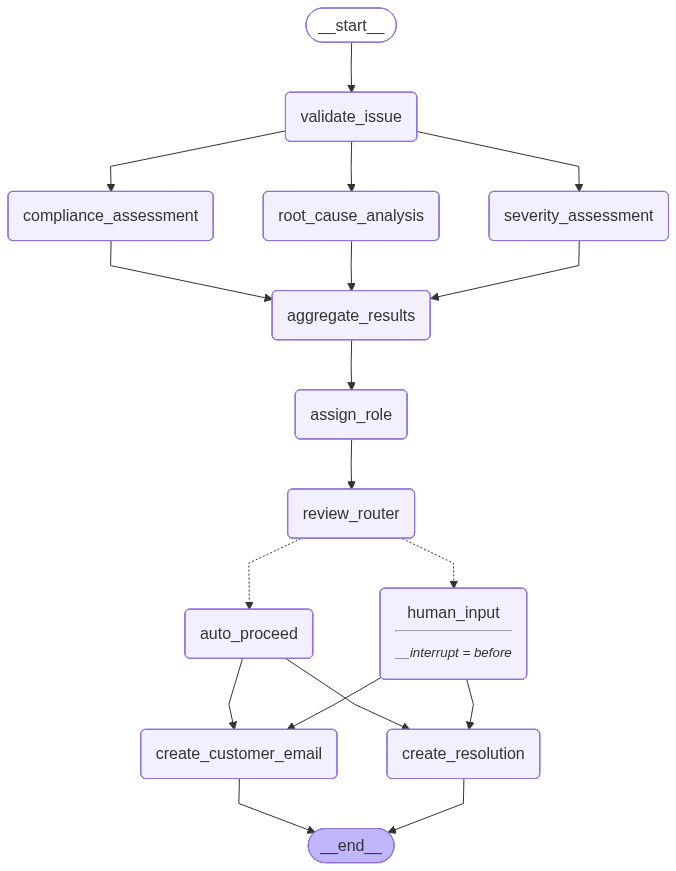

In [123]:
parallel = StateGraph(State)

parallel.add_node("validate_issue", validate_issue)
parallel.add_node("root_cause_analysis", root_cause_analysis)
parallel.add_node("severity_assessment", severity_assessment)
parallel.add_node("compliance_assessment", compliance_assessment)
parallel.add_node("aggregate_results", aggregate_results)
parallel.add_node("assign_role", assign_role)
parallel.add_node("review_router", review_router)
parallel.add_node("auto_proceed", lambda state: {})  # passthrough node
parallel.add_node("human_input", human_input)
parallel.add_node("create_resolution", create_resolution)
parallel.add_node("create_customer_email", create_customer_email)

parallel.add_edge(START, "validate_issue")
parallel.add_edge("validate_issue", "root_cause_analysis")
parallel.add_edge('validate_issue', 'severity_assessment')
parallel.add_edge('validate_issue', 'compliance_assessment')
parallel.add_edge('root_cause_analysis', 'aggregate_results')
parallel.add_edge('severity_assessment', 'aggregate_results')
parallel.add_edge('compliance_assessment', 'aggregate_results')
parallel.add_edge('aggregate_results', 'assign_role')
parallel.add_edge("assign_role", "review_router")     # ← goes to router first
parallel.add_conditional_edges(
    "review_router",
    route_decision,
    {
        "human_input": "human_input",
        "auto_proceed": "auto_proceed"
    }
)
parallel.add_edge('human_input', 'create_resolution')
parallel.add_edge('human_input', 'create_customer_email')
parallel.add_edge("auto_proceed", "create_resolution")
parallel.add_edge("auto_proceed", "create_customer_email")
parallel.add_edge('create_customer_email', END)
parallel.add_edge('create_resolution', END)

memory = MemorySaver()

compiled_parallel = parallel.compile(checkpointer=memory, interrupt_before=["human_input"])

display(Image(compiled_parallel.get_graph().draw_mermaid_png()))

# Invoke

In [124]:
config = {"configurable": {"thread_id": "complaint_001"}}

# First run — goes until interrupt
for node in compiled_parallel.stream({
    "issue": "Incorrect information on your report",
    "product": "Credit reporting or other personal consumer reports",
    "narrative": "Kindly address this issue on my credit report..."
}, config=config):
    print(node)

# Check if pipeline paused
state = compiled_parallel.get_state(config)

if state.next == ("human_input",):
    print("\n⚠️  HUMAN REVIEW REQUIRED")
    print(f"Reasons: {state.values['review_reasons']}")
    print(f"Issue: {state.values['valid_issue']}")
    print(f"Severity: {state.values['severity']}/10")
    print(f"Compliance: {state.values['compliance']}/10")
    print(f"Team: {state.values['team']}")
    
    decision = input("\n[A]pprove or [E]dit & Approve? ").strip().lower()
    
    if decision == "e":
        updates = {}
        new_severity = input(f"New severity (1-10) or Enter to skip: ").strip()
        new_compliance = input(f"New compliance (1-10) or Enter to skip: ").strip()
        new_team = input(f"New team or Enter to skip: ").strip()
        
        if new_severity: updates["severity"] = int(new_severity)
        if new_compliance: updates["compliance"] = int(new_compliance)
        if new_team: updates["team"] = new_team
        
        if updates:
            compiled_parallel.update_state(config, updates)
            print(f"✏️  Updated: {updates}")
    
    # Resume pipeline
    print("\n▶️  Resuming...")
    for node in compiled_parallel.stream(None, config=config):
        print(node)

else:
    print("\n✅ Auto-processed — no review needed")

{'validate_issue': {'valid_issue': 'Incorrect information on your report', 'valid_product': 'Credit reporting or other personal consumer reports', 'confidence': 0.97}}
{'compliance_assessment': {'compliance': 2, 'compliance_explanation': 'The narrative is a routine consumer request to correct inaccurate information on a credit report. It does not indicate fraud, illegal activity, violence, or other high-risk conduct. The compliance risk is low because it relates to standard credit reporting dispute handling.'}}
{'severity_assessment': {'severity': 8, 'severity_explanation': 'This appears to involve incorrect information on a credit report, which can significantly affect a consumer’s ability to obtain credit, housing, employment, or favorable loan terms. Because errors in consumer reports can have broad financial and personal consequences, the issue is high severity, though the exact impact is unclear from the brief narrative.'}}
{'root_cause_analysis': {'root_cause': 'The issue appears

In [125]:
config = {"configurable": {"thread_id": "complaint_001"}}

for node in compiled_parallel.stream({
    "issue": "Incorrect information on your report",
    "product": "Credit reporting or other personal consumer reports",
    "narrative": "Kindly address this issue on my credit report. I assert that this account is not mine and believe it to be fraudulent. I urge you to correct this mistake and have provided supporting documents for verification."
    }, config=config):
    print(node)

{'validate_issue': {'valid_issue': 'Incorrect information on your report', 'valid_product': 'Credit reporting or other personal consumer reports', 'confidence': 0.98}}
{'severity_assessment': {'severity': 8, 'severity_explanation': 'This describes an allegedly fraudulent account appearing on a credit report, which can materially affect creditworthiness, loan approvals, and financial opportunities. While the narrative does not mention identity theft confirmation or immediate financial loss, incorrect or fraudulent credit reporting is a serious consumer reporting issue with potentially significant impact.'}}
{'compliance_assessment': {'compliance': 3, 'compliance_explanation': 'The narrative is a consumer dispute about potentially fraudulent or inaccurate credit-report information and requests correction with supporting documents. This is a standard, legitimate credit reporting complaint and does not itself contain threats, explicit harassment, or other high-risk content. The main compli